<a href="https://colab.research.google.com/github/JamieASM/user-testing-resources/blob/main/Task-Sheet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Conjure Blocks User Testing Task Sheet - Textual Essence
- Author: Jamie Melton
- Created: 18th March 2026

---

## Before you begin

This sheet is one of **two sheets** we shall ask you to complete. All tasks on this sheet require you to present your answers using the constraint programming language '*Essence*'. *Essence* is the input language to conjure, and is text-based. Note that we do not expect participants to have used Essence prior to this study, and thus will signpost to any appropriate information you may need when completing a task. That being said, if you feel it is appropriate to do so, you are also allowed to refer to the full conjure documentation, which can be found here: https://conjure.readthedocs.io/en/latest/.

Once you have completed both task sheets, you will then be asked to complete a questionnaire. The questionnaire will ask you about your experience using both constraint programming representations, and for feedback on the *Conjure Blocks* tool.

For this sheet, your solutions to each task will be completed using *this* Jupyter notebook file. Whilst the tasks on this sheet are required to be completed in the order by which they are presented, if you find a task to be too difficult to complete or to be causing frustration, you are more than welcome to move to the next task. Note, every task on this sheet has a solution and tasks further down the sheet increase in their difficulty. You are *not* being tested on your ability to complete a task or knowledge of constraint programming. Furthermore, you are reminded that you are allowed to withdraw yourself from this study at any point, no questions asked.

---

## How to use Jupyter Notebooks:

Below is a code block:

In [ ]:
print("Hello world")

Hello world


Before running any solutions you make, please ensure that the code block under 'Setting Up Conjure' has been ran. If you do not do this, you will experience the following error:

`UsageError: Cell magic '%%conjure' not found.`

If you have any more questions about using Jupyter Notebooks, please don't hesitate to ask the researchers.

---

## Setting Up Conjure

In [3]:
!source <(curl -s https://raw.githubusercontent.com/conjure-cp/conjure-notebook/v0.0.9/scripts/install-colab.sh)
%reload_ext conjure

Installing Conjure version v2.5.1 and Conjure Notebook version v0.0.9...
Conjure is already installed.
Conjure notebook is already installed.
Conjure: The Automated Constraint Modelling Tool
Release version 2.5.1
Repository version a9cbc2e (2023-11-07 23:44:00 +0000)


<IPython.core.display.Javascript object>

Conjure extension is loaded.
For usage help run: %conjure_help


---

---

## Task 1

### Briefing

You have been provided the following essence program:

In [ ]:
%%conjure

letting y be 5, z be 7
    find x: int(0..10)
    such that (x == y) /\ (x < z)]

The final answer should be '`x = 6`', but this is not currently the case. Change the code in the code block below such that the final answer becomes '`x = 6`'.

In [1]:
%%conjure

letting y be 5, z be 7
    find x: int(0..10)
    such that (x == y) /\ (x < z)]

UsageError: Cell magic `%%conjure` not found.


---

## Task 2

### Background Information

Task 2 surrounds a problem known as the 'Chicken Nugget Problem'. The problem works as follows:

Imagine you are at McDonald's and want to buy chicken nuggets. As of February 2026, chicken nuggets can be purchased in quantities of 6, 9, and 20 pieces. That means:

- You *could* purchase *15 chicken nuggets* (a 6-piece pack and a 9-piece pack) or *18 chicken nuggets* (three 6-piece packs or two 9-piece packs).
- *But* you could *not* purchase *10 chicken nuggets* -- there is no combination of 6, 9 and 20 that could make 10.

Given this, what is the *maximum* number of chicken nuggets that we *cannot* purchase?[1]

### Briefing

You have been provided the following essence program:

In [ ]:
%%conjure

letting maxVal be 200

{!!!REDACTED!!!}
such that
    {}(exists x : int(0..maxVal) .
      exists y : int(0..maxVal) .
      exists z : int(0..maxVal) .
      6*x + 9*y + 20*z = N)
maximising N

The program is missing a section of its functionality (highlighted by `{!!!REDACTED!!!}` or `{}`). Identify what is missing and add it back in to the code block below.

In [4]:
%%conjure

letting maxVal be 200

{!!!REDACTED!!!}
such that
    {}(exists x : int(0..maxVal) .
      exists y : int(0..maxVal) .
      exists z : int(0..maxVal) .
      6*x + 9*y + 20*z = N)
maximising N

```json
{"N": 43}
```

---

## Task 3

### Background Information

Task 3 surrounds another problem known as the 'Magic Square Problem'. The problem works as follows:

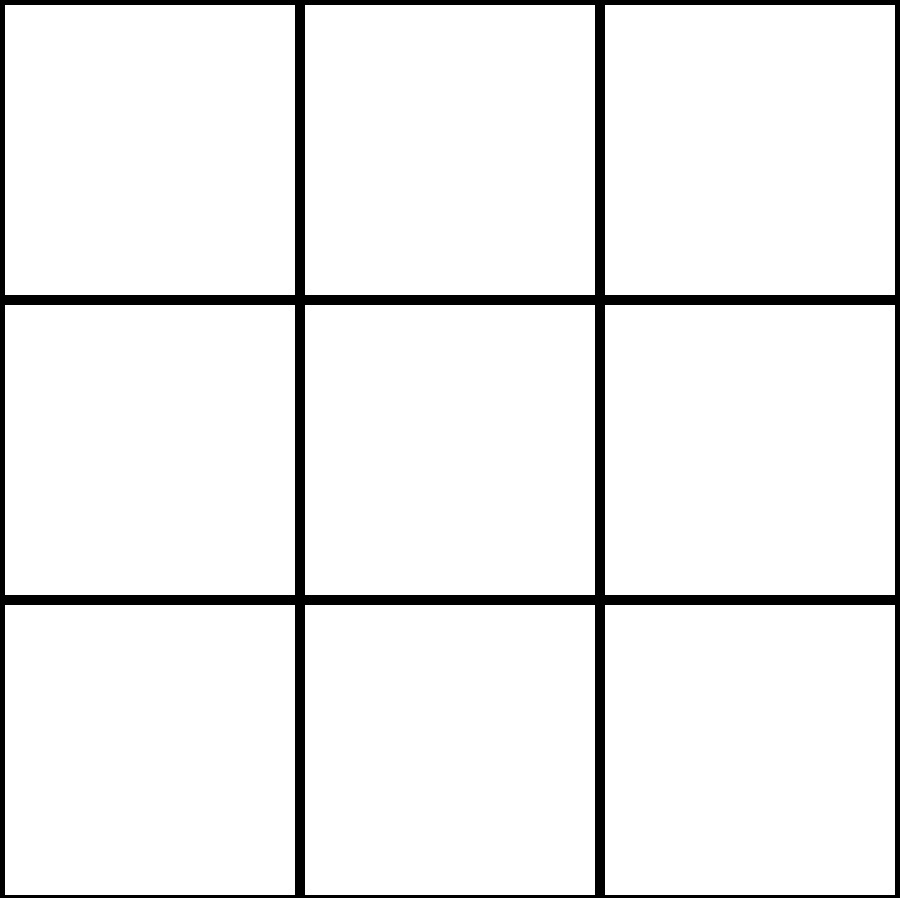

This is a *3 x 3 grid*. In each cell of the grid, we want:

- To place a number from *1 to 9* into each cell, such that each number only exists on the grid *once* (just like Sudoku!).
- For every row, column, and main diagonal to *equal the same sum*.

For example, a 4 x 4 magic square problem would have the following solution:

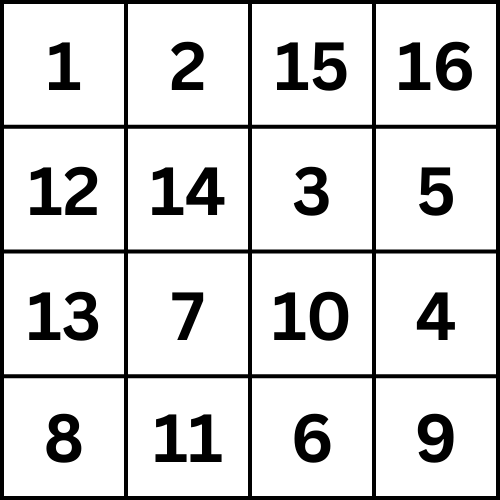

### Briefing

You have been provided the following essence program:

In [ ]:
%%conjure

given n : int(1..3)

letting Index be domain int(n..1),

        Value be domain int(1..n**2)

find square : matrix indexed by [Index,Index] of Value,
     s : int(1..sum i : int(n**2+1-n..n**2) . i)

letting
    allDiff(flatten(square)),
    forAll r : Index . (sum c : Index . square[r,c]) = s,
    forAll c : Index . (sum r : Index . square[r,c]) = s,
    (maximise d : Index . square[d,d]) = s,
    (sum d : Index . square[d,n+1-d]) = s

The solution should be:

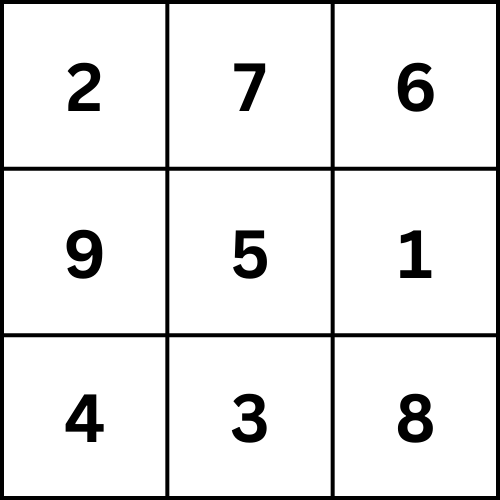

There are mistakes across this program that are preventing conjure from finding a solution. Identify these problems, and change them in the code block below so that the correct solution is found.

In [6]:
%%conjure

given n : int(1..3)

letting Index be domain int(n..1),

        Value be domain int(1..n**2)

find square : matrix indexed by [Index,Index] of Value,
     s : int(1..sum i : int(n**2+1-n..n**2) . i)

letting
    allDiff(flatten(square)),
    forAll r : Index . (sum c : Index . square[r,c]) = s,
    forAll c : Index . (sum r : Index . square[r,c]) = s,
    (maximise d : Index . square[d,d]) = s,
    (sum d : Index . square[d,n+1-d]) = s

```json
{"s": 15, "square": {"1": {"1": 2, "2": 7, "3": 6}, "2": {"1": 9, "2": 5, "3": 1}, "3": {"1": 4, "2": 3, "3": 8}}}
```

[2] To more easily verify your answer, you can run the code block below:

In [29]:
for i in square:

  for j in square[i]:
    print(square[i][j], end = "  ")

  print()

2  7  6  
9  5  1  
4  3  8  


## Bibliography

[1] S. (https://math.stackexchange.com/users/25240/ssumner), “General McNugget problem.” [Online]. Available:
https://math.stackexchange.com/q/340802

[2] T. Walsh, “CSPLib Problem 019: Magic Squares and Sequences.”